In [1]:
%matplotlib notebook

import matplotlib.pyplot as plt
import numpy as np
import cv2

<IPython.core.display.Javascript object>


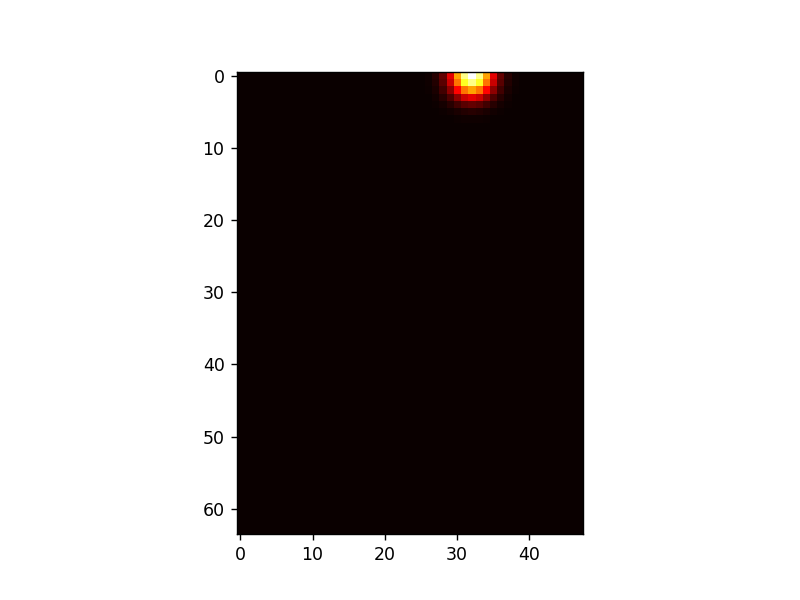

In [2]:
def generate_heatmap(heatmap, sigma):

    shape = heatmap.shape
#     print(shape)
    tmp_size = sigma * 3           # 这里控制高斯核大小，可改为你想要的高斯核大小
    mu_x = 0            # x坐标
    mu_y = 32            # y坐标
    ul = [int(mu_x - tmp_size), int(mu_y - tmp_size)]           # 关键点高斯分布左上角坐标，[18，26］
    br = [int(mu_x + tmp_size + 1), int(mu_y + tmp_size + 1)]   # 关键点高斯分布右下角坐标，[31，39］
    size = 2 * tmp_size + 1              # 高斯核大小
    x = np.arange(0, size, 1, np.float32)
    y = x[:, np.newaxis]
    x0 = y0 = size // 2       # 6
    g = np.exp(- ((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma ** 2))
#     print(g)
    g_x = max(0, -ul[0]), min(br[0], shape[0]) - ul[0]   # (0,13) 差值为2 * tmp_size + 1，即size大小
    g_y = max(0, -ul[1]), min(br[1], shape[1]) - ul[1]   # (0,13)
    img_x = max(0, ul[0]), min(br[0], shape[0])   # (26,39)
    img_y = max(0, ul[1]), min(br[1], shape[1])   # (18,31)
    heatmap[img_x[0]:img_x[1], img_y[0]:img_y[1]] = g[g_x[0]:g_x[1], g_y[0]:g_y[1]]
#     heatmap[img_y[0]:img_y[1], img_x[0]:img_x[1]] = g[g_y[0]:g_y[1], g_x[0]:g_x[1]]
    am = np.amax(heatmap)
    heatmap /= am / 255
    return heatmap


target = np.zeros((64, 48))    # h，w
sigma = 2
plt.imshow(target, cmap='hot', interpolation='nearest')
plt.show()
target = generate_heatmap(target, sigma)
plt.imshow(target, cmap='hot', interpolation='nearest')
plt.show()                # 显示图像
# print(target)


In [7]:
def gen_heatmap(heatmap_size, image_size, joints):
    
    sigma = 2
    tmp_size = sigma * 3
    num_joints = len(joints)
    
    # target: [num_joints, heatmap_size, heatmap_size]
    target = np.zeros((num_joints, heatmap_size[0], heatmap_size[1]), dtype=np.float32)
    # target_weight: [num_joints, 1] (1-dim, 1:visible, 0:invisible)
    target_weight = np.ones((num_joints,1), dtype=np.float32)
    
    # 生成一张图像的heatmap
    for joint_id in range(num_joints):
        feat_stride = image_size / heatmap_size
        # 高斯核中心在热力图上的位置
        mu_x = int(joints[joint_id][0] / feat_stride[0] + 0.5)
        mu_y = int(joints[joint_id][1] / feat_stride[1] + 0.5)
        # gaussian range, ul:left-top, br:right-down
        ul = [int(mu_x-tmp_size), int(mu_y-tmp_size)]
        br = [int(mu_x+tmp_size+1), int(mu_y+tmp_size+1)]
        # 这一段貌似没有什么用
        if ul[0] > heatmap_size[0] or ul[1] >= heatmap_size[1] or br[0] < 0 or br[1] < 0:
            target_weight[joint_id] = 0
            continue
        
        # gaussian kernel size
        size = 2 * tmp_size + 1
        x = np.arange(0, size, 1, np.float32)
        y = x[:, np.newaxis]
        x0 = y0 = size // 2
        # 高斯分布 z = e^(-((x-x0)^2+(y-y0)^2) / (2*σ^2)）
        g = np.exp(-((x-x0)**2+(y-y0)**2) / (2*sigma**2) ) 
        g_x = max(ul[0], 0)-ul[0], min(br[0], image_size[0])-ul[0]
        g_y = max(ul[1], 0)-ul[1], min(br[1], image_size[1])-ul[1]
        # image range
        img_x = max(ul[0], 0) , min(br[0], image_size[0])
        img_y = max(ul[1], 0) , min(br[1], image_size[1])
        
        # select confident joints
        v = target_weight[joint_id]
        if v > 0.5:
            target[joint_id][img_x[0]:img_x[1] , img_y[0]:img_y[1]] \
                = g[g_x[0]:g_x[1] , g_y[0]:g_y[1]]
        
        return target
            

# main
joints = np.array([[100, 100, 1]])
heatmap_size = np.array([128, 128])
image_size = np.array([128, 128])
heatmap = gen_heatmap(heatmap_size, image_size, joints)
print(heatmap.shape)

heatmap = heatmap[0]
am = np.amax(heatmap)
heatmap /= am / 255
plt.imshow(heatmap, cmap='hot', interpolation='nearest')
plt.show()